In [44]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [45]:
X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()

X_val = pd.read_csv("../data/processed/X_val.csv")
y_val = pd.read_csv("../data/processed/y_val.csv").values.ravel()

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

In [46]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_val_pred = lr.predict(X_val)
print("Logistic Regression Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Logistic Regression Accuracy: 0.6416666666666667
              precision    recall  f1-score   support

           0       0.67      0.53      0.59      4321
           1       0.65      0.78      0.71      8040
           2       0.57      0.41      0.47      2639

    accuracy                           0.64     15000
   macro avg       0.63      0.57      0.59     15000
weighted avg       0.64      0.64      0.63     15000



/Users/aidar/credit-risk-ml-system/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,  
    random_state=42,
    solver='lbfgs',
)

# GridSearch for C and penalty
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2']  # lbfgs just l2
}

# We can add l1 with another solver
param_grid_lr_extended = [
    {
        'solver': ['lbfgs'],
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100]
    }
]

grid_lr = GridSearchCV(
    log_reg,
    param_grid_lr_extended, 
    cv=5,
    scoring='f1_macro',  
    n_jobs=-1,
    verbose=1
)

# Training
grid_lr.fit(X_train_scaled, y_train)

print("\nBest LR Params:", grid_lr.best_params_)
print("Best CV F1-Macro:", grid_lr.best_score_)

# Predicting
y_val_pred_lr = grid_lr.predict(X_val_scaled)
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_lr))

Fitting 5 folds for each of 15 candidates, totalling 75 fits


/Users/aidar/credit-risk-ml-system/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/aidar/credit-risk-ml-system/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/aidar/credit-risk-ml-system/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in ve


Best LR Params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1-Macro: 0.6069240169677274

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.68      0.64      4321
           1       0.77      0.50      0.61      8040
           2       0.43      0.79      0.55      2639

    accuracy                           0.60     15000
   macro avg       0.60      0.66      0.60     15000
weighted avg       0.66      0.60      0.61     15000



In [47]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_val_pred = rf.predict(X_val)
print("Random Forest Accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

Random Forest Accuracy: 0.7092666666666667
              precision    recall  f1-score   support

           0       0.76      0.66      0.71      4321
           1       0.71      0.81      0.75      8040
           2       0.62      0.49      0.55      2639

    accuracy                           0.71     15000
   macro avg       0.70      0.65      0.67     15000
weighted avg       0.71      0.71      0.70     15000



In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Model
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# Parameter distribution
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': randint(2, 10)
}

# Randomized search
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Train
random_search.fit(X_train, y_train)

# Results
print("Best params:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

# Validation
y_pred = random_search.predict(X_val)
print(classification_report(y_val, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 6, 'n_estimators': 100}
Best CV score: 0.795236829700279
              precision    recall  f1-score   support

           0       0.78      0.86      0.82      4321
           1       0.85      0.78      0.82      8040
           2       0.75      0.80      0.77      2639

    accuracy                           0.81     15000
   macro avg       0.79      0.81      0.80     15000
weighted avg       0.81      0.81      0.81     15000



In [39]:
X_train = X_train.drop('Occupation_CreditMix', axis=1)
X_val = X_val.drop('Occupation_CreditMix', axis=1)

In [40]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Model
xgb = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# Parameter distribution
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}

# Random search
random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Train
random_search.fit(X_train, y_train)

# Results
print("Best params:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

# Validation
y_pred = random_search.predict(X_val)
print(classification_report(y_val, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/aidar/credit-risk-ml-system/venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [02:17:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/aidar/credit-risk-ml-system/venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [02:17:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/aidar/credit-risk-ml-system/venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [02:17:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/aidar/credit-risk-ml-system/venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [02:17:40] WARNING: /Users/runner/work/xgboost/xgboost/src/

Best params: {'colsample_bytree': np.float64(0.76553213116505), 'learning_rate': np.float64(0.09330198957407325), 'max_depth': 8, 'n_estimators': 430, 'subsample': np.float64(0.7973035063015821)}
Best CV score: 0.7747683353687848
              precision    recall  f1-score   support

           0       0.78      0.81      0.79      4321
           1       0.81      0.81      0.81      8040
           2       0.77      0.73      0.75      2639

    accuracy                           0.79     15000
   macro avg       0.79      0.78      0.78     15000
weighted avg       0.79      0.79      0.79     15000



## **Feature Selection**


Top 10 features:
                   feature  importance
5            Interest_Rate    0.108353
11        Outstanding_Debt    0.104005
13      Credit_History_Age    0.077807
7      Delay_from_due_date    0.076326
9     Changed_Credit_Limit    0.057834
10    Num_Credit_Inquiries    0.054396
17          Debt_to_Income    0.054097
3        Num_Bank_Accounts    0.046618
8   Num_of_Delayed_Payment    0.042309
4          Num_Credit_Card    0.040864


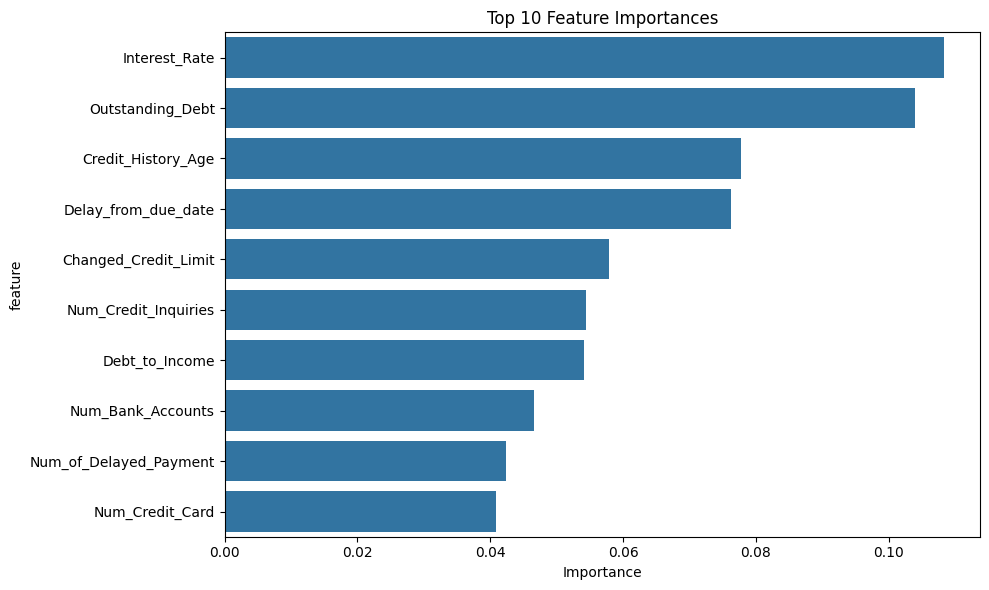

In [50]:
# Лучшая модель из Random Search
best_rf = random_search.best_estimator_

# Теперь смотрим feature importance
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
})
importance = importance.sort_values('importance', ascending=False)

# Покажем топ-10
print("\nTop 10 features:")
print(importance.head(10))

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()